# Week 9 Overview

This week will be a mix of data vizualization problems and . 

The first 5 problems are data cleaning and the final 4 problems are linear algebra. 

### Data Visualization

Data visualization is a key part of exploratory data analysis (EDA), a crucial initial step for understanding a dataset and preparing for statistical modeling.

Helps visually answer questions such as:
- what patterns are evident in the data?
- what variables are important?
- does the data have anomalies or outliers?

Data visualization is also used throughout the data analysis process to show results and convey information to stakeholders.

Typically, EDA uses `histograms` & `box plots` to visualize `distribution` of a single continuous variable. `Bar charts` & `scatterplots` are used for `bivariate analysis` - correlation between two variables.


#### Histograms

![histograms](https://raw.githubusercontent.com/brendenwest/cis276/main/images/histograms.png)

Display the distribution of a continuous variable.
- Useful for visualizing the shape, for identifying
patterns or trends, for detecting
outliers, skewness, or multimodality
- Divides data into equal-width intervals (`bins`)
- Height of each `bar` represents frequency or
`count` of observations
- Can also compare the distribution of two
or more variables


#### Box & Whisker Plots

A box plot can show how tightly data is grouped, how the data is skewed, and also the symmetry of data.

![image](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-2.png)

Display `median`, `quartiles`, and outliers.
- Useful for visualizing the distribution and spread.
- Box represents `interquartile range` (IQR)
- Line inside the box represents the median
- Whiskers extend from box to minimum and maximum values within 1.5 times the IQR from the box
- Values outside of this range are considered outliers and plotted as individual points


#### Scatterplots

Scatter (aka X-Y) plots show the relationship between two continuous variables. Also useful for identifying outlier data points.

![scatterplots](https://www.mathsisfun.com/data/images/correlation-examples.svg)



#### Bar Charts

Useful for visualizing distribution of `categorical` variables through relative size of bars.

-  One axis represents categories being compared
- Other axis represents frequency, count, or percentage of each category
- usually has space between bars to avoid confusion with histograms

![bar_chart](https://www.mathsisfun.com/data/images/bar-chart-movies.svg)


### Plotting with matplotlib

matplotlib is python package designed for creating (mostly two-dimensional) publication-quality plots.

It allows interactive plotting from the iPython shell or within Jupyter notebooks

matplotlib can export visualizations to  common vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.).

- plots & plot types
- title & labels
- legends
- subplots
- annotations
- saving plots

### Plotting with pandas

The pandas `plot()` method is a wrapper for matplotlib's pyplot.plot() and produces the same plots, but with simpler syntax for visualizing dataframes.
`.plot()` has several optional parameters. Most notably, the `kind` parameter  determines which kind of plot you’ll create (default is a `line` plot):

- "area" for area plots.
- "bar" for vertical bar charts.
- "barh" for horizontal bar charts.
- "box" for box plots.
- "hexbin" for hexbin plots.
- "hist" for histograms.
- "kde" for kernel density estimate charts.
- "density" an alias for "kde".
- "line" for line graphs.
- "pie" for pie charts.
- "scatter" for scatter plots.

### Plotting with seaborn

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn not only makes it easier than pandas to prepare a wider variety of plots, but supports enhancements for presentation-quality plots.

Seaborn supports several key types of plots:

- **relational** - show the relationship between two numeric variables. Includes scatter plots and line plots
- **categorical** - compare data in different categories
- **distribution** - examine how numeric data is distributed across a range of values. Types of distribution plots are histogram, kernel density estimate (KDE) plot, and empirical cumulative distribution function (ECDF) plot
- **predictive** - plots that are designed for predictive analysis, such as for linear regression models.

#### Seaborn styles

`set_style(style)`
Sets the background style with one of these values: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks` (the default). This style stays in effect until it is changed by another set_style() call.
#### General vs. specific methods

You can create Seaborn plots using the general `relplot()` command, which expects a `kind` parameter.

Alternatively, you can use a specific method - e.g. `lineplot()`, which does not require a `kind` parameter.

The two approaches mostly produce the same result, but the the general methods let you create plots with subplots, while the specific methods don’t.

So the general methods return a `FacetGrid` object that contains an `Axes` object for each subplot. The specific methods return an `Axes` object.

#### Basic Seaborn plot parameters

- data - the DataFrame of data to plot
- kind - the type of plot (general plots only)
- x, y - data columns for the x- and y-axis
- hue -  the column that determines categories to plot, with different color for each category
- palette -  color pallette for the plot
- height - The height of the plot in inches with a default of 5. (general plots only)
- aspect - the ratio of width to height (general plots only)
- legend - options for how the legend will be drawn: `auto` (the default), `brief`, `full`, and `False`. (general plots only)

#### Creating subplots

- By default, x and y labels are shared by subplots
- subplots get their title from the category label

#### Modifying plot features

The `Axes` object that provides methods for enhancing a plot.

#### Saving plots

Seaborn plots can be saved to PNG, SVG, or PDF files. The approach is slightly different for plots created with general or specific methods.

- **General method** - assign the plot's FacetGrid object to a variable and then use the `savefig()` method of the FacetGrid object
- **Specific method** - call the `get_figure()` method on the Axes object  returned by the lineplot() method, then chain go the `savefig()` method

# Data Visualization Problems

For the problems this week we are going to go a step deeper and start to ask questions about our data. 

In [2]:
import pandas as pd
import seaborn as sns

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::disability-and-health-insurance-seattle-neighborhoods/about
dis_health_df = pd.read_csv('seattle_data/disability_health_insurance_Neighborhoods.csv')
dis_health_df.columns = [i.replace(" ", "_") for i in dis_health_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::poverty-and-employment-status-seattle-neighborhoods/about
income_df = pd.read_csv('seattle_data/incomes_Neighborhoods.csv')
income_df.columns = [i.replace(" ", "_") for i in income_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::incomes-occupations-and-earnings-seattle-neighborhoods/about
poverty_df = pd.read_csv('seattle_data/poverty_Neighborhoods.csv')
poverty_df.columns = [i.replace(" ", "_") for i in poverty_df.columns]

## Problem 1: Asking Questions (10 pts)

Take 5 minutes to look through the above data sources as pose 5 analytical questions you might want to ask with that data. By analytical I mean question will drive informative analysis. For example:

**Good Question**: Is there relationship between health insurance coverage and disability?

**Bad Question**: How many neighboorhoods are there?

The second question is the type of question that is is good to ask when processing the data to make sure you processed it correctly but it doesn't give you insights into the data.

At least two of the questions must involve data from at least two of the datasets.

In class you will share your questions with your group and as a group you will pick two questions to focus on for analysis in class. On your own this week you will answer the rest of your questions.

**Grading**
You will receive 2 points per question. One point for forming a question the other for it being a analytical question. 

In [3]:
# 1. Do neighborhoods with higher poverty rates tend to also have higher unemployment rates?

# 2. Do neighborhoods with higher disability rates tend to also have higher poverty rates?

# 3. Do neighborhoods with higher average incomes have higher rates of health insurance coverage?

# 4. Are neighborhoods with lower incomes more likely to have higher poverty rates?

# 5. Do neighborhoods with more residents with disabilities also tend to have higher unemployment rates?

## Problem 2: Data Cleaning and Merging (10 pts)

Take a few minutes to prepare your data for analysis. You can decide what preparation is required but you must at least perform two of the following to receive credit. You might find that you start to create a graph and then need to prepare the data better (i.e. remove an outlier) that is expected.

1. Clean up the column names.
2. Merge dataframes together. 
3. Fill in null values.
4. Removing outliers. 
5. Change the shape of the data (We will learn aggregations next week but if you know how feel free to use them).
6. Any other preparation required to answer your questions.

For each preparation step add a comment to explain why you did that step. 

**Grading** You will receive 5 points for the first two data prep steps you perform. 2 point will be for the comment and then 3 points will be for accurately performing the prep. 

In [7]:
# Clean column names 
dis_health_df.columns = [c.lower().replace(" ", "_") for c in dis_health_df.columns]
income_df.columns = [c.lower().replace(" ", "_") for c in income_df.columns]
poverty_df.columns = [c.lower().replace(" ", "_") for c in poverty_df.columns]

# Make sure the neighborhood column has the same name in all datasets
dis_health_df = dis_health_df.rename(columns={"neighborhood_name": "neighborhood"})
income_df = income_df.rename(columns={"neighborhood_name": "neighborhood"})
poverty_df = poverty_df.rename(columns={"neighborhood_name": "neighborhood"})

# Merge so everything is in one dataframe
merged_df = dis_health_df.merge(income_df, on="neighborhood", how="inner")
merged_df = merged_df.merge(poverty_df, on="neighborhood", how="inner")

merged_df.head()

,objectid_x,neigh_no_x,neighborhood,neighborhood_type_x,neighborhood_subtype_x,acs_vinatage_x,population_18_years_and_over,population_18_to_64_years,population_18_to_64_years_below_poverty_with_a_disability,population_18_to_64_years_below_poverty_without_a_disability,...,population_20_to_64_years_employed,population_20_to_64_years_below_poverty_employed,people_with_income_to_poverty_below_2.00,population_20_to_64_years_in_civilian_labor_force,population_20_to_64_years_in_civilian_labor_force_below_poverty,population_20_to_64_years_not_in_labor_force,population_20_to_64_years_not_in_labor_force_below_poverty,population_20_to_64_years_unemployed,population_20_to_64_years_unemployed_below_poverty,neighborhood_type_(outside_comp_plan_areas_id)
0,1,1.4,Alki/Admiral,CRA,Southwest,5Y23,10131,7910,105,323,...,6567,109,1087,6729,163,1079,265,162,54,CRA
1,2,2.1,North Delridge,CRA,Delridge Neighborhoods,5Y23,5213,4629,28,408,...,3574,64,948,3866,207,717,229,292,143,CRA
2,3,2.2,High Point,CRA,Delridge Neighborhoods,5Y23,6828,6084,128,584,...,4448,110,3172,4632,160,1332,522,184,50,CRA
3,4,2.3,Riverview,CRA,Delridge Neighborhoods,5Y23,3940,3497,29,147,...,3023,90,600,3098,105,348,61,75,15,CRA
4,5,2.4,Roxhill/Westwood,CRA,Delridge Neighborhoods,5Y23,11602,10014,397,454,...,8232,145,2389,8579,300,1151,538,347,155,CRA


## Problem 3: Question 1 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

Question:
Do neighborhoods with higher poverty rates tend to also have higher unemployment rates?

Finding:
The scatter plot shows a positive relationship between poverty rates and unemployment rates. Neighborhoods with higher poverty levels tend to also have higher unemployment.

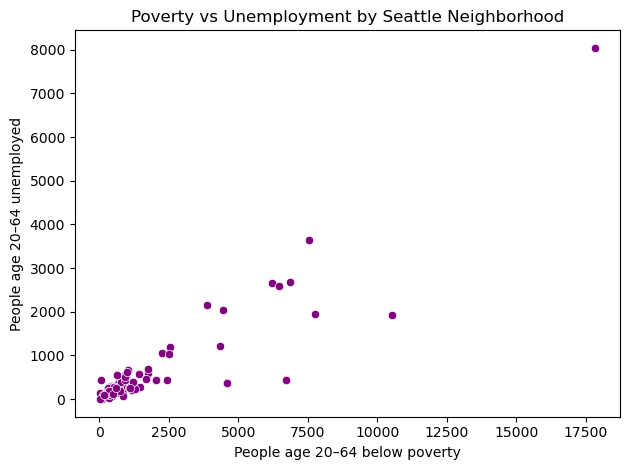

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot poverty vs unemployment to see if they move together
sns.scatterplot(
    data=merged_df,
    x="population_20_to_64_years_below_poverty",
    y="population_20_to_64_years_unemployed",
    color="purple"  # Changed color so points stand out
)

plt.title("Poverty vs Unemployment by Seattle Neighborhood")  # Added a clear title
plt.xlabel("People age 20–64 below poverty")
plt.ylabel("People age 20–64 unemployed")

plt.tight_layout()
plt.show()

## Problem 4: Question 2 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

Question:
Do neighborhoods with higher average incomes have higher rates of health insurance coverage?

Finding:
The plot suggests a positive relationship: neighborhoods with higher income tend to have a higher percent of residents with health insurance (and fewer uninsured).

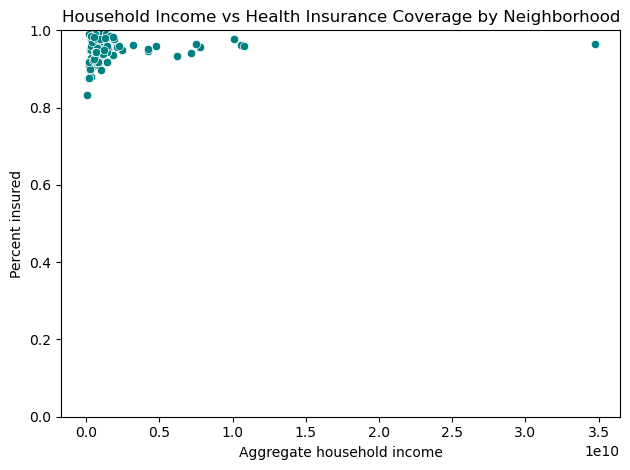

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate insurance rate so neighborhoods are comparable
plot_df = merged_df.copy()
plot_df["insured_rate"] = 1 - (plot_df["population_without_health_insurance"] / plot_df["population_civilian_noninstitutionalized"])

# Scatter plot: income vs insured rate
sns.scatterplot(
    data=plot_df,
    x="aggregate_household_income",
    y="insured_rate",
    color="teal"  # Changed color so points stand out
)

plt.title("Household Income vs Health Insurance Coverage by Neighborhood")  # Added a clear title
plt.xlabel("Aggregate household income")
plt.ylabel("Percent insured")

plt.ylim(0, 1)  # Set y-axis to 0–100% so the scale is honest and easy to read
plt.tight_layout()
plt.show()

## Problem 5: Question 3 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

Question:
Do neighborhoods with more residents with disabilities also tend to have higher unemployment rates?

Finding:
The visualization shows that neighborhoods with more residents with disabilities tend to also have higher unemployment numbers, suggesting a possible relationship between disability and unemployment levels.

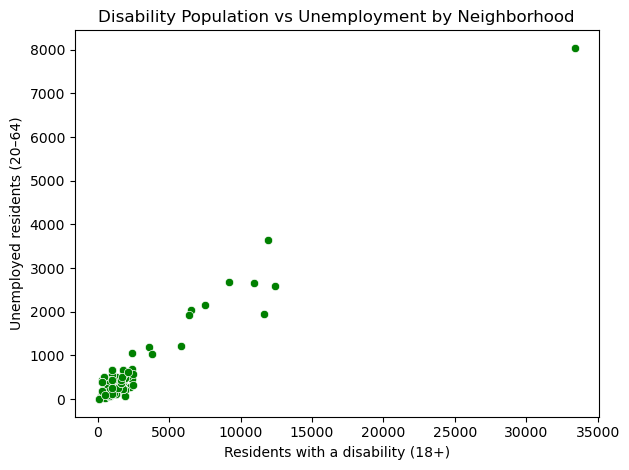

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: disability vs unemployment
sns.scatterplot(
    data=merged_df,
    x="population_18_years_and_over_with_a_disability",
    y="population_20_to_64_years_unemployed",
    color="green"  # Changed color so points are easy to see
)

plt.title("Disability Population vs Unemployment by Neighborhood")  # Added descriptive title
plt.xlabel("Residents with a disability (18+)")
plt.ylabel("Unemployed residents (20–64)")

plt.tight_layout()  # Adjust layout so labels fit well
plt.show()

## Problem 6: Question 4 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

Question:
Are neighborhoods with lower incomes more likely to have higher poverty rates?

Finding:
The visualization suggests that neighborhoods with lower income levels tend to have higher numbers of residents living below the poverty line, indicating a relationship between income and poverty.

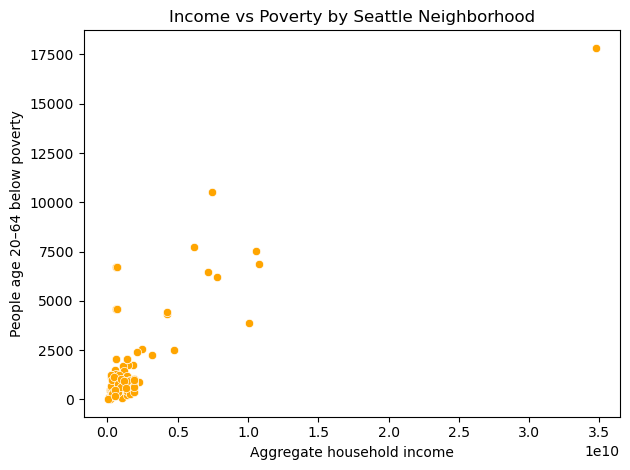

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: income vs poverty
sns.scatterplot(
    data=merged_df,
    x="aggregate_household_income",
    y="population_20_to_64_years_below_poverty",
    color="orange"  # Changed color so the points are easy to see
)

plt.title("Income vs Poverty by Seattle Neighborhood")  # Added descriptive title
plt.xlabel("Aggregate household income")
plt.ylabel("People age 20–64 below poverty")

plt.tight_layout()  # Adjust layout so labels display correctly
plt.show()

## Problem 7: Question 5 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

Question:
Do neighborhoods with higher disability rates tend to have lower income levels?

Finding:
The visualization suggests that neighborhoods with higher numbers of residents with disabilities often have lower household income levels, indicating a possible relationship between disability rates and income.

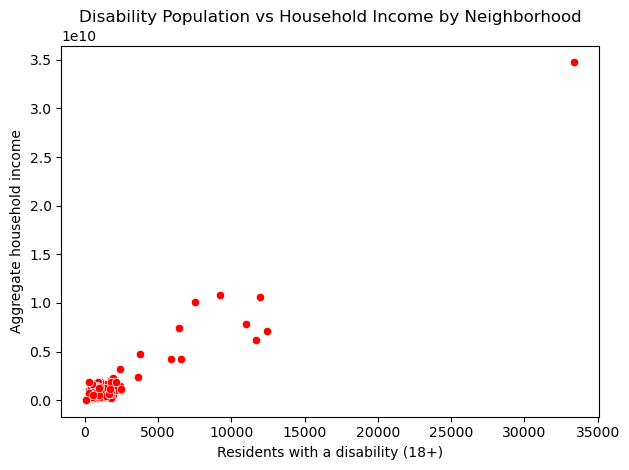

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: disability vs income
sns.scatterplot(
    data=merged_df,
    x="population_18_years_and_over_with_a_disability",
    y="aggregate_household_income",
    color="red"  # Changed color so the points stand out
)

plt.title("Disability Population vs Household Income by Neighborhood")  # Added descriptive title
plt.xlabel("Residents with a disability (18+)")
plt.ylabel("Aggregate household income")

plt.tight_layout()  # Adjust layout so labels fit properly
plt.show()

## Problem 8 (10pts)
Pick 5 columns in the datasets above and create a covariance by completing the following steps:

1. Mean center all columns. You can use panda's mean function for this. 
2. Create a covariance matrix as follows:
$$ C = X^T X \dfrac{1}{n-1}$$
3. You should save this to a dateframe called `cov_df` to be used in the next problem. 
4. Output the results of `cov_df` and visually check your results against [DataFrame.cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html). The numbers should match. 

In [15]:
import pandas as pd

# I selected five numeric columns that represent different aspects of the data
# These are good choices because covariance measures how variables change together.

cols = [
    "population_20_to_64_years_below_poverty",
    "population_20_to_64_years_unemployed",
    "population_18_years_and_over_with_a_disability",
    "aggregate_household_income",
    "population_without_health_insurance"
]

# Create a new dataframe with only these five variables so the math is easier to work with
X = merged_df[cols]

# Mean center the data
# This step subtracts the average of each column from every value in that column.
# Mean centering is required because covariance measures variation around the mean.
X_centered = X - X.mean()

# Convert the dataframe to a matrix so we can apply the matrix covariance formula
X_matrix = X_centered.values

# Get the number of rows. 
# This will be used in the covariance formula.
n = X_matrix.shape[0]

# Apply the covariance formula from the assignment:
# C = (X^T * X) / (n - 1)
cov_matrix = (X_matrix.T @ X_matrix) / (n - 1)

# Convert the covariance matrix back into a dataframe so it is easier to read
# and so the rows/columns are labeled with the variable names
cov_df = pd.DataFrame(cov_matrix, index=cols, columns=cols)

# Output the covariance matrix we calculated
cov_df

,population_20_to_64_years_below_poverty,population_20_to_64_years_unemployed,population_18_years_and_over_with_a_disability,aggregate_household_income,population_without_health_insurance
population_20_to_64_years_below_poverty,5.518546e+06,1.667811e+06,6.733090e+06,6.242984e+12,3.155911e+06
population_20_to_64_years_unemployed,1.667811e+06,7.264744e+05,2.867486e+06,2.784949e+12,1.217639e+06
population_18_years_and_over_with_a_disability,6.733090e+06,2.867486e+06,1.198662e+07,1.121243e+13,5.205619e+06
aggregate_household_income,6.242984e+12,2.784949e+12,1.121243e+13,1.145606e+19,4.744644e+12
population_without_health_insurance,3.155911e+06,1.217639e+06,5.205619e+06,4.744644e+12,2.409797e+06


## Problem 9 (10pts)

Next you will take the `cov_df` and create a correlation matrix from it. The formula for this is

$$ R = SCS $$

Where $C$ is the covariance matrix `cov_df`, and $S$ is a diagonal matrix of reciprocated standard deviations per variable (that is, the ith diagonal is $\dfrac{1}{\sigma_i}$ where $\sigma_i$ is the standard deviation of variable i). You can use panda's standard deviation function to create $S$. 

Once you have created the correlation matrix visually compare it to [np.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)

In [17]:
import numpy as np
import pandas as pd

# First calculate the standard deviation for each variable.
# The standard deviation tells us how spread out each variable is.
std_vals = X.std()

# Create the S matrix described in the formula.
# S is a diagonal matrix where each diagonal value is 1 / standard deviation.
# This rescales the covariance matrix so that the values become correlations.
S = np.diag(1 / std_vals)

# Convert the covariance dataframe to a matrix so we can apply matrix multiplication
C = cov_df.values

# Apply the correlation matrix formula from the assignment:
# R = S * C * S
corr_matrix = S @ C @ S

# Convert the matrix back to a dataframe so the rows and columns are labeled
corr_df = pd.DataFrame(corr_matrix, index=cov_df.index, columns=cov_df.columns)

# Show the correlation matrix we calculated
corr_df

,population_20_to_64_years_below_poverty,population_20_to_64_years_unemployed,population_18_years_and_over_with_a_disability,aggregate_household_income,population_without_health_insurance
population_20_to_64_years_below_poverty,1.000000,0.832960,0.827854,0.785167,0.865411
population_20_to_64_years_unemployed,0.832960,1.000000,0.971724,0.965360,0.920276
population_18_years_and_over_with_a_disability,0.827854,0.971724,1.000000,0.956827,0.968576
aggregate_household_income,0.785167,0.965360,0.956827,1.000000,0.903017
population_without_health_insurance,0.865411,0.920276,0.968576,0.903017,1.000000
